# PyMC

La implementación práctica de los conceptos teóricos de **Monte Carlo vía Cadena de Markov** (MCMC) se realiza mediante bibliotecas de programación
probabilística como PyMC.

Se describe y analiza un modelo bayesiano implementado en PyMC para caracterizar el **conocimiento de usuarios** (θ) y la **dificultad de tareas** (β). La base de datos utilizada contiene información sobre 70 usuarios y 21 tareas, donde 1 representa la resolución correcta, 0 la incorrecta y existen datos faltantes.



El objetivo es obtener las distribuciones a posteriori de todos los parametros mediante la Cadena de Markov Monte Carlo implementado en PyMC, para luego realizar inferencias sobre el conocimiento de los usuarios y la dificultad de las tareas.




## Carga de datos

La base de datos utilizada se le aplicó una conversión a tipo numerico forzando los valores no válidos a np.nan. El conjunto de datos resultante consta de 70 usuarios y 20 tareas.

In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
from pymc import model_to_graphviz
import matplotlib.pyplot as plt
from scipy.special import expit

!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/TA136.csv


--2025-11-26 17:04:55--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/TA136.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6109 (6.0K) [text/plain]
Saving to: ‘TA136.csv.2’

TA136.csv.2         100%[===================>]   5.97K  --.-KB/s    in 0s      

2025-11-26 17:04:55 (54.7 MB/s) - ‘TA136.csv.2’ saved [6109/6109]



In [2]:
df= pd.read_csv("TA136.csv", header=None)
df = df.iloc[1:, 1:].reset_index(drop=True)

# Convertir todas las columnas a tipo numérico, forzando errores a NaN
df = df.apply(pd.to_numeric, errors='coerce')
X_obs = df.values.astype(float)

# Dimensiones
n_usuarios, n_tareas = X_obs.shape
print(f"Datos cargados: {n_usuarios} usuarios x {n_tareas} tareas")

Datos cargados: 70 usuarios x 20 tareas


## Construccion del modelo bayesiano

El modelo se define de la siguiente manera:


*   **Conocimiento del usuario** i : $\theta_i \sim \mathcal{N}(\mu_{\theta}, \sigma_\theta^2)$
*   **Dificultad de la tarea** j : $\beta_i \sim \mathcal{N}(\mu_{\beta}, \sigma_\beta^2)$
*   **Hiperparametros de las medias**: $\mu_\beta,\mu_\theta\sim\mathcal{N}(0,1)$
*   **Hiperparametros de las desviaciones estandar**: $\sigma_\theta, \sigma_\beta \sim\text{Exp}(1)$
*   **Variable observable** : $X_{i,j}\sim\text{Ber}(\sigma(\theta_i - \beta_j))$

La funcion sigmoide mapea la diferencia entre el conomiento del usuario y la dificultad de la tarea a una probabilidad de éxito $P(X_{i,j} = 1)$. Un $\theta_i$ alto implica un mayor conocimiento y un $\beta_j$ alto implica una mayor dificultad. Si $\theta_i > \beta_j$ el usuario tiene una probabilidad de éxito P > 0.5 y viceversa.

In [3]:
with pm.Model() as model:

    # Hiperparámetros para el conocimiento de los usuarios (θ)
    mu_theta = pm.Normal('mu_theta', mu=0, sigma=1)
    sigma_theta = pm.Exponential('sigma_theta', lam=1)

    # Hiperparámetros para la dificultad de las tareas (β)
    mu_beta = pm.Normal('mu_beta', mu=0, sigma=1)
    sigma_beta = pm.Exponential('sigma_beta', lam=1)

    # Conocimiento de cada usuario θ_i ~ N(μ_θ, σ²_θ)
    theta = pm.Normal('theta', mu=mu_theta, sigma=sigma_theta, shape=n_usuarios)

    # Dificultad de cada tarea β_j ~ N(μ_β, σ²_β)
    beta = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=n_tareas)

    # Lógica del modelo: p = σ(θ_i - β_j)
    diff = theta[:, None] - beta[None, :]

    # Variable observable X_{i,j} ~ Bernoulli(σ(θ_i - β_j))
    obs = pm.Bernoulli('obs', p=pm.math.sigmoid(diff), observed=df)


/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1305: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1319: ImputationWarning: Data in obs contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


## Gráfico de la red bayesiana

La red bayesiana visualiza la estructura jerárquica del modelo. Las **elipses no sombreadas** representan variables latentes o parámetros, mientras que la **elipse sombreada** (obs_observed) representa las observaciones (datos).



*   **Jerarquía de  θ**  : Los hiperparametros $\mu_\theta$ y $\sigma_\theta$ influyen en el parámetro $\theta$ de cada uno de los 70 usuarios.
*   **Jerarquía de β**  : Los hiperparametros $\mu_\beta$ y $\sigma_\beta$ influyen en el parámetro $\beta$ de cada uno de las 20 tareas.
*   **Vinculo observacional** : Las variables θ y β se combinan para determinar la probabilidad $P(X_{i,j} = 1)$ a través de la función sigmoide que a su vez modela la variable observada obs.

### Interpretación de los datos faltantes

Los datos faltantes se interpretan como variables latentes no observadas que necesitan ser imputadas. En la red esto se refleja en dos nodos:

1.  *obs_observed* (sombreado) : Representa la parte de la matriz de datos que si fue observada (los 0 y 1 preestablecidos por el dataset).
2.  *obs_unobserved* : Representa la parte de la matriz de datos que está faltando (np.nan).

Ambos nodos dependen de los parámetros θ y β, durante el muestreo el algoritmo actualiza las distribuciones a posteriori de tanto estos parametros, los hiperparametros como de los valores faltantes.



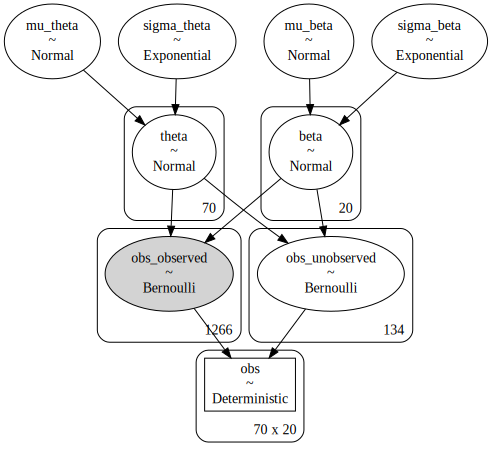

In [4]:
graph = model_to_graphviz(model)
display(graph)

## Muestreo y diagnostico de convergencia

Se realizo el muestreo con 3 cadenas con los siguientes parametros:


*   *draws* = 3000  (número de muestras posteriores a guardar por cadena)
*   *tune* = 2500   (número de pasos iniciales)
*   *chains* = 3 (cadenas de Markov indep)
*   *target_accept* = 0.95

Además se verificaron los criterios de convergencia y calidad de las muestras en los parametros $\theta_i$ y $\beta_j$, de manera que $ESS_{bulk} > 30$  y $\hat{R} \leq 1.1$.

Esto se hizo mediante la utilización de la función *summary* donde genera un resumen diagnóstico sobre todos los parámetros de interés.
Los criterios se establecieron para asegurar que las tres cadenas muestrearan de manera eficiente la misma distribución a posteriori.
*   $\hat{R}$ : El estadistico mide la convergencia comparando la varianza entre cadenas con la varianza dentro de cada cadena. Se busca que $\hat{R}$ sea menor o igual a 1.1 que indica que las cadenas se han mezclado correctamente.
*   $ESS_{bulk}$ : Estima el número de muestras independientes que son equivalentes en términos estadisticos a las muestras correlacionadas. Es una medida de la eficiencia del muestreo, un valor bajo indica una fuerte autocorrelacion dentro de las cadenas. El valor de 30 se utiliza como un umbral mínimo aceptable.

In [19]:
with model:
    idata = pm.sample(
        draws=3000,
        tune=500,
        chains=3,
        target_accept=0.9,
        random_seed=10,
    )


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [20]:
# Obtener resumen de TODOS los parámetros θ y β
summary = az.summary(idata, var_names=['theta', 'beta'])

# Extraer métricas clave
ess_bulk_theta = summary.filter(like='theta', axis=0)['ess_bulk']
ess_bulk_beta = summary.filter(like='beta', axis=0)['ess_bulk']
rhat_theta = summary.filter(like='theta', axis=0)['r_hat']
rhat_beta = summary.filter(like='beta', axis=0)['r_hat']

# ESS (bulk)
min_ess_theta = ess_bulk_theta.min()
min_ess_beta = ess_bulk_beta.min()
min_ess_total = min(min_ess_theta, min_ess_beta)

print(f"  - Criterio: > 30 → {'✓ CUMPLE' if min_ess_total > 30 else '✗ NO CUMPLE'}")

# R-hat
max_rhat_theta = rhat_theta.max()
max_rhat_beta = rhat_beta.max()
max_rhat_total = max(max_rhat_theta, max_rhat_beta)

print(f"  - Criterio: ≤ 1.1 → {'✓ CUMPLE' if max_rhat_total <= 1.1 else '✗ NO CUMPLE'}")




  - Criterio: > 30 → ✓ CUMPLE
  - Criterio: ≤ 1.1 → ✓ CUMPLE


## Estimación de esperanzas a posteriori

Se estimo la esperanza a posteriori $E[\cdot | datos]$ para cada parámetro $\theta_i$ y $\beta_j$ utilizando la media de las muestras posteriores.




In [21]:
# Calcular las medias posteriores (promediando sobre todas las cadenas y draws)
posterior_means = idata.posterior.mean(dim=["chain", "draw"])
theta_mean = posterior_means["theta"].values  # Array de 70 elementos (conocimientos)
beta_mean = posterior_means["beta"].values    # Array de 20 elementos (dificultades)

# Caracterización de Tareas (beta): Mayor beta = más difícil
idx_tarea_facil = np.argmin(beta_mean)
idx_tarea_dificil = np.argmax(beta_mean)

# Caracterización de Usuarios (theta): Mayor theta = mejor desempeño
idx_mejor_usuario = np.argmax(theta_mean)
idx_peor_usuario = np.argmin(theta_mean)

print(f"     Tarea más fácil:    Índice {idx_tarea_facil:2d}  ")
print(f"     Tarea más dificil:  Índice {idx_tarea_dificil:2d}  ")
print(f"     Usuario con mejor desempeño:  Índice {idx_mejor_usuario:2d}  ")
print(f"     Usuario con peor desempeño:   Índice {idx_peor_usuario:2d}  ")


     Tarea más fácil:    Índice  0  
     Tarea más dificil:  Índice 15  
     Usuario con mejor desempeño:  Índice 51  
     Usuario con peor desempeño:   Índice 50  


## Distribuciones a posteriori de hiperparámetros

El gráfico de las densidades a posteriori de los hiperparámetros proporciona información sobre las caracteristicas de la población de usuarios y tareas.

*   En la **media de conocimientos** podemos ver que la distribución está centrada en un valor ligeramente positivo. Esto sugiere que el conocimiento promedio de la población de usuarios está por encima de cero.
*   En la **media de dificultades** la distribución se centra en un valor negativo, esto indica que las tareas son más fáciles que el nivel de conocimiento promedio de los usuarios ($\mu_\theta > \mu_\beta$)
*   En la **desviación estándar de conocimientos** la distribución muestra un valor de dispersión moderado, indicando que hay una variación significativa en las habilidades entre los 70 usuarios.
*   En la **desviación estándar de dificultades** la distribución muestra un valor de dispersión ligeramente mayor que $\sigma_\theta$.

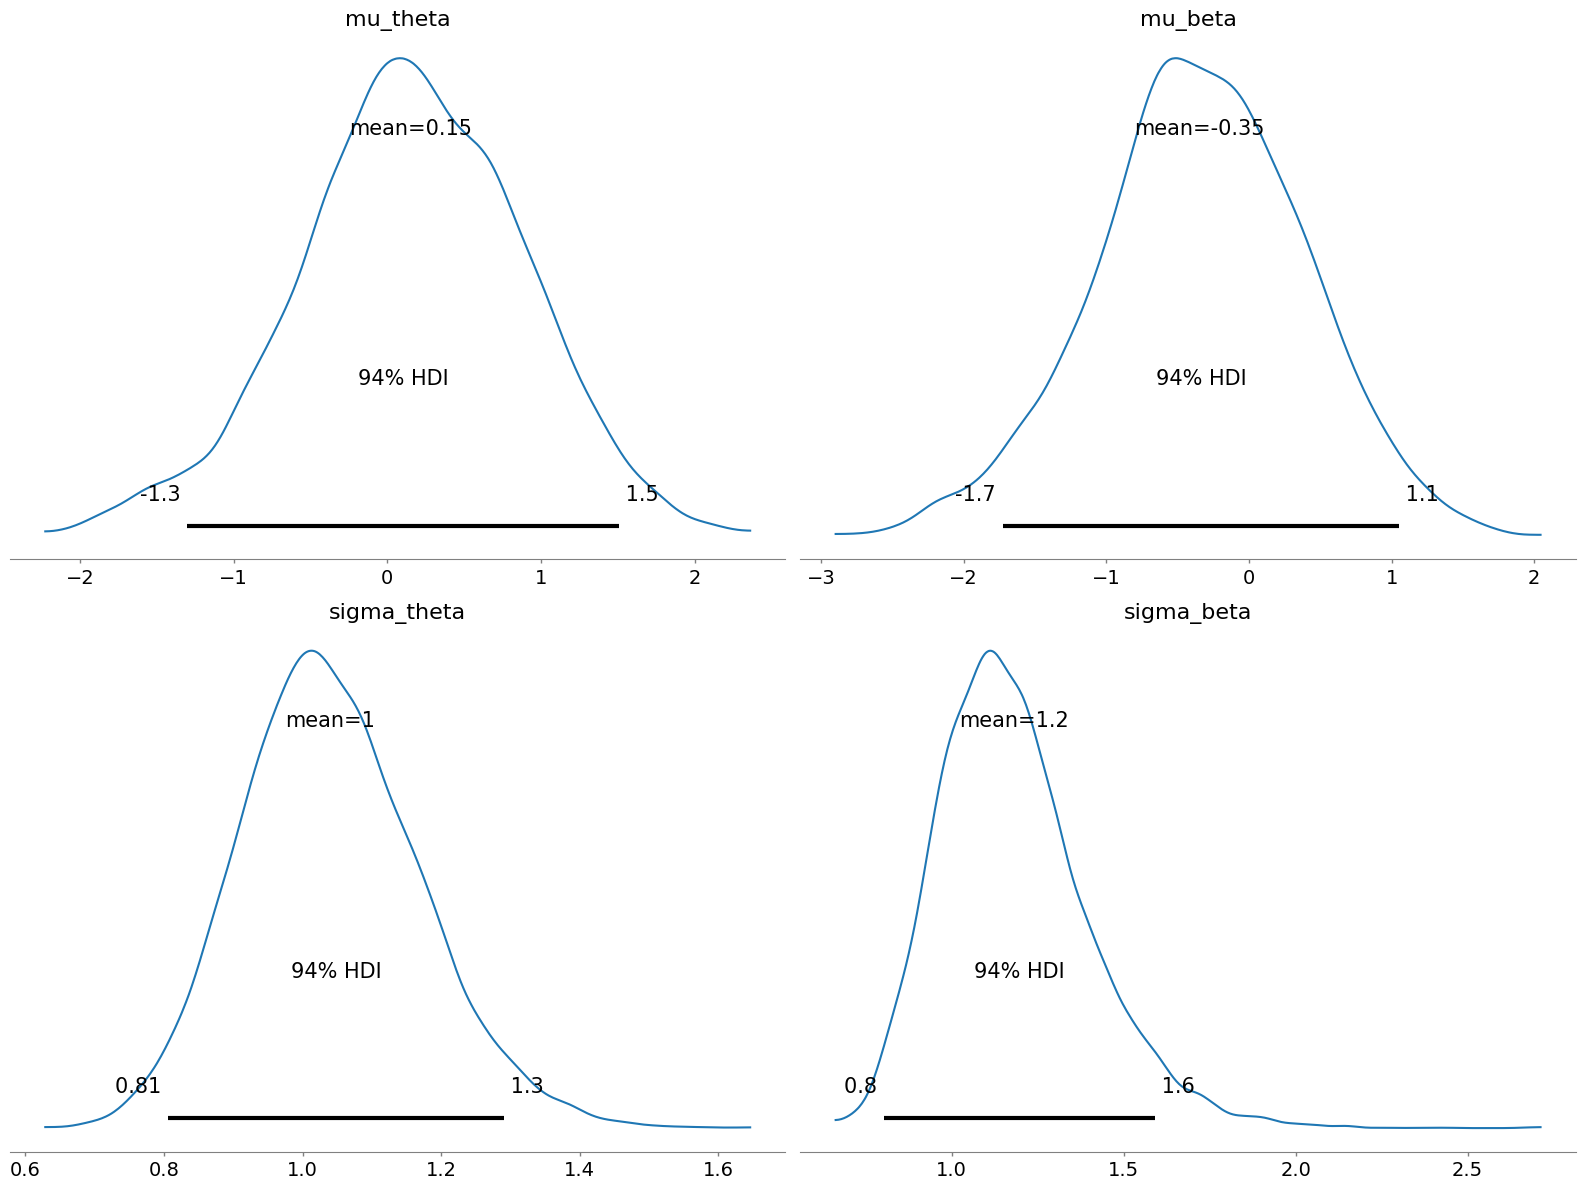

In [22]:
hiperparametros = ["mu_theta", "mu_beta", "sigma_theta", "sigma_beta"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
az.plot_posterior(idata, var_names=hiperparametros, hdi_prob=0.94, ax=axes.flatten())
plt.tight_layout()
plt.show()

## Probabilidad predictiva

Se aproximo la probabilidad predictiva a posteriori de que el usuario i-ésimo resuelva la tarea j-ésima $P(X_{i,j}=1|datos)$, que se estima mediante:
$$P(X_{i,j}=1|datos)\approx \frac{1}{S}\sum_{s=1}^S \sigma (\theta_i^{(s)}-\beta_j^{(s)})$$

### Caso especifico: Usuario 4, Tarea 12

Se calculo la probabilidad predictiva de que el usuario 4  resuelva la tarea 12. El promedio de la probabilidad predictiva es aprox 87.11%, dado que la probabilidad es superior al 50%, el modelo predice con alta certeza que el Usuario 4 resuelve la Tarea 12.

Este resultado implica que el conocimiento posterior medio estimado del Usuario 4 es mayor que la dificultad posterior media estimada de la Tarea 12.



In [23]:
def prob_predictiva_por_cadena(usuario_idx, tarea_idx,idata_obj):

    theta_s = idata_obj.posterior["theta"].values
    beta_s = idata_obj.posterior["beta"].values
    n_chains = theta_s.shape[0]
    probs_por_cadena = []

    for chain in range(n_chains):
        theta_chain = theta_s[chain, :, usuario_idx]
        beta_chain = beta_s[chain, :, tarea_idx]
        # Calcular E[σ(θ - β)]
        prob_chain = expit(theta_chain - beta_chain).mean()
        probs_por_cadena.append(prob_chain)

    return np.array(probs_por_cadena)

usuario_4 = 4
tarea_12 = 12
probs_4_12 = prob_predictiva_por_cadena(usuario_4, tarea_12, idata)

for chain_idx, prob in enumerate(probs_4_12):
    print(f"   Cadena {chain_idx + 1}: P(X_4,12 = 1) = {prob:.6f} ({100*prob:.2f}%)")


   Cadena 1: P(X_4,12 = 1) = 0.871101 (87.11%)
   Cadena 2: P(X_4,12 = 1) = 0.870542 (87.05%)
   Cadena 3: P(X_4,12 = 1) = 0.871243 (87.12%)
